In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/DATA/mushrooms.csv')

In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


<Axes: xlabel='class', ylabel='count'>

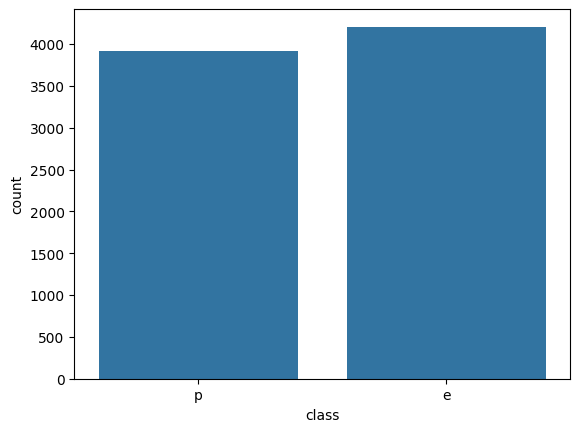

In [4]:
sns.countplot(data=df, x='class')

In [5]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [8]:
feat_uni = df.describe().transpose().reset_index().sort_values('unique')

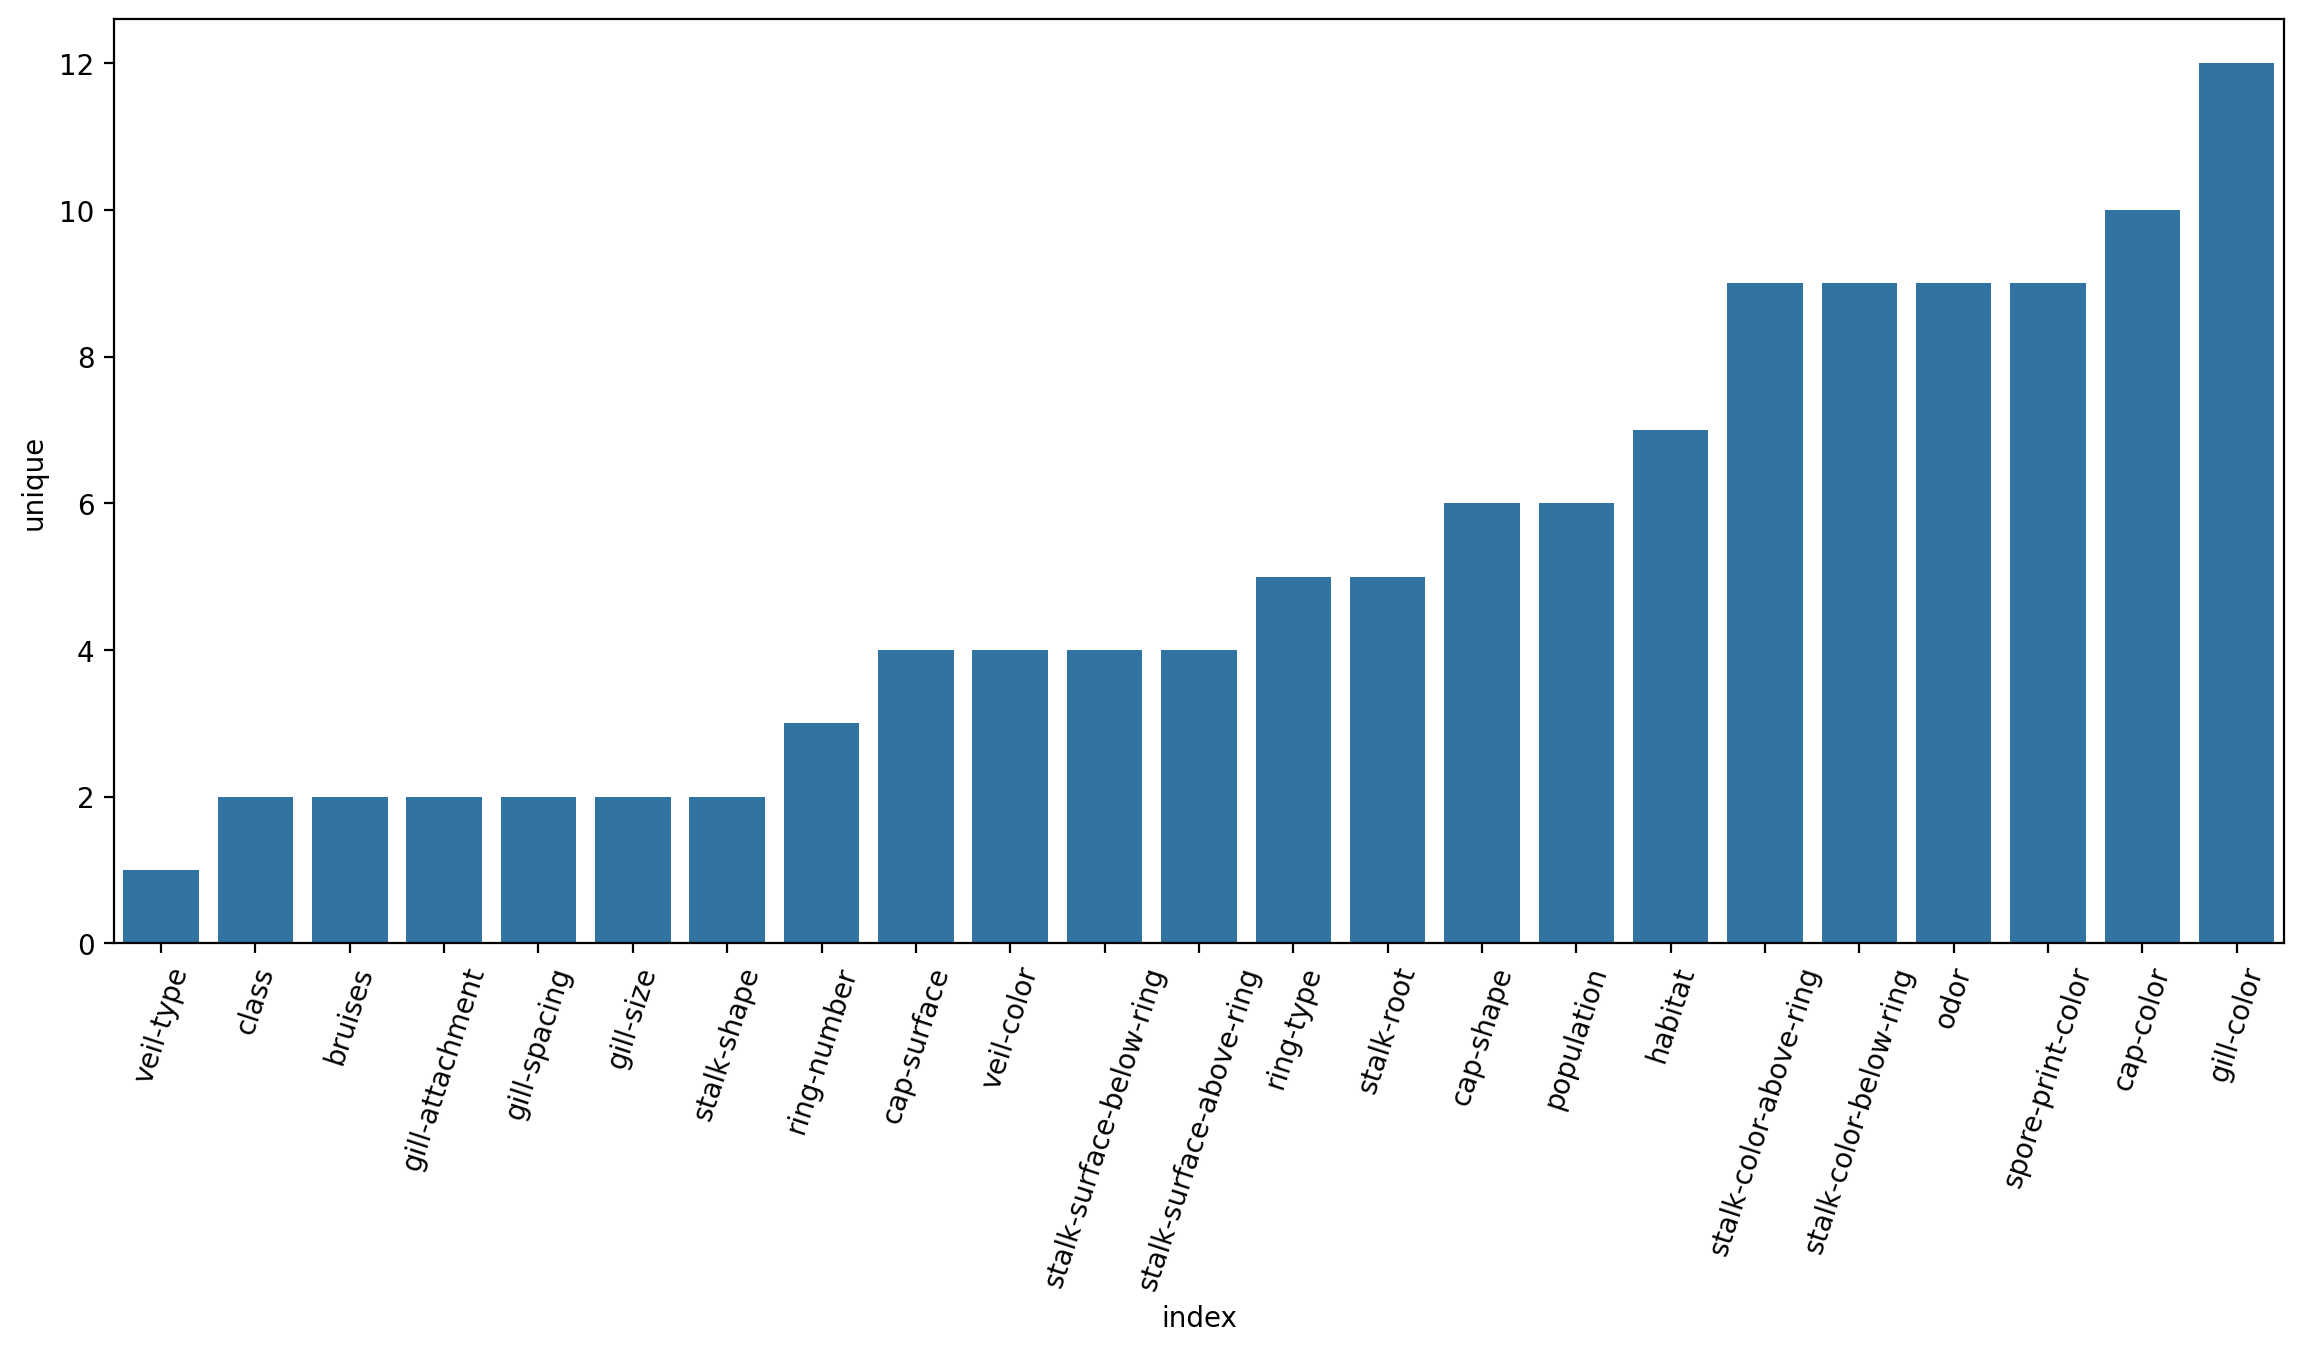

In [12]:
plt.figure(figsize=(14,6), dpi=200)
sns.barplot(data=feat_uni, x='index', y='unique')
plt.xticks(rotation=72);

In [13]:
X = df.drop('class', axis=1)

In [15]:
#X.isnull().sum()

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [17]:
y = df['class']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [20]:
from sklearn.ensemble import AdaBoostClassifier

In [21]:
model = AdaBoostClassifier(n_estimators=10)

In [22]:
model.fit(X_train, y_train)

,estimator,None
,n_estimators,10
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [23]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array(['e', 'p', 'p', ..., 'e', 'p', 'e'], shape=(1219,), dtype=object)

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           e       0.94      0.98      0.96       637
           p       0.97      0.94      0.96       582

    accuracy                           0.96      1219
   macro avg       0.96      0.96      0.96      1219
weighted avg       0.96      0.96      0.96      1219



In [29]:
model.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.12254742,
       0.10804924, 0.        , 0.18966778, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.09574638, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.14677603, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [30]:
model.feature_importances_.argmax()

np.int64(22)

In [33]:
X.columns[22]

'odor_n'

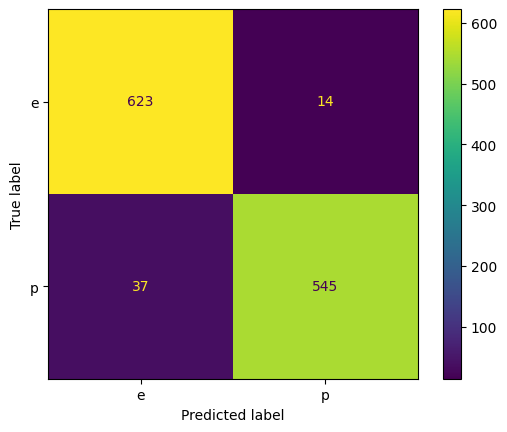

In [34]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

<Axes: xlabel='odor', ylabel='count'>

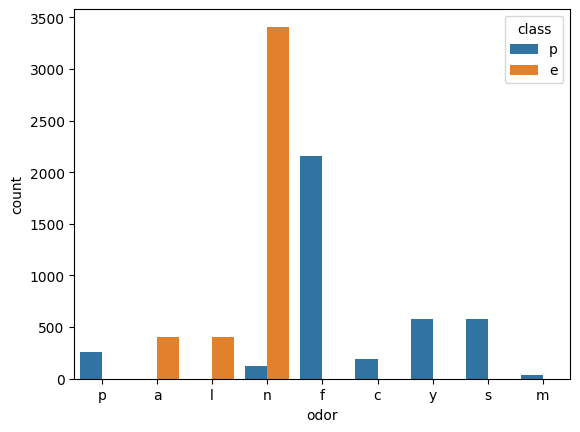

In [36]:
sns.countplot(data=df, x='odor', hue='class')

In [37]:
error_rates = []

for n in range(1,96):
    model = AdaBoostClassifier(n_estimators=n)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    error = 1 - accuracy_score(y_test, preds)
    error_rates.append(error)


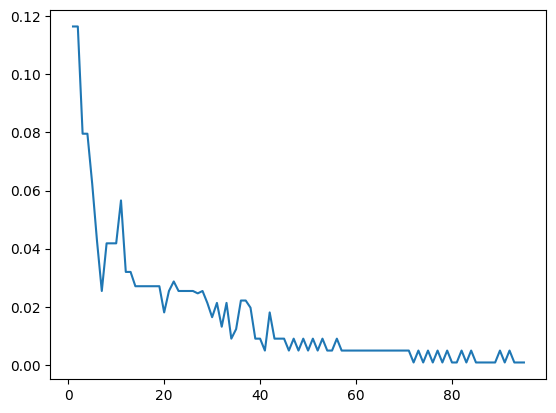

In [39]:
plt.plot(range(1,96), error_rates)

In [40]:
model = AdaBoostClassifier(n_estimators=41)

In [41]:
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           e       0.94      0.98      0.96       637
           p       0.97      0.94      0.96       582

    accuracy                           0.96      1219
   macro avg       0.96      0.96      0.96      1219
weighted avg       0.96      0.96      0.96      1219



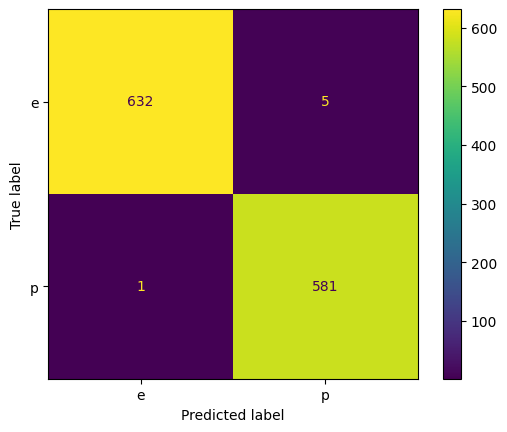

In [43]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [61]:
feats = pd.DataFrame(index=X.columns, data=model.feature_importances_, columns=['Importance'])

In [62]:
imp_feats = feats[feats['Importance'] > 0]

<Axes: xlabel='None', ylabel='Importance'>

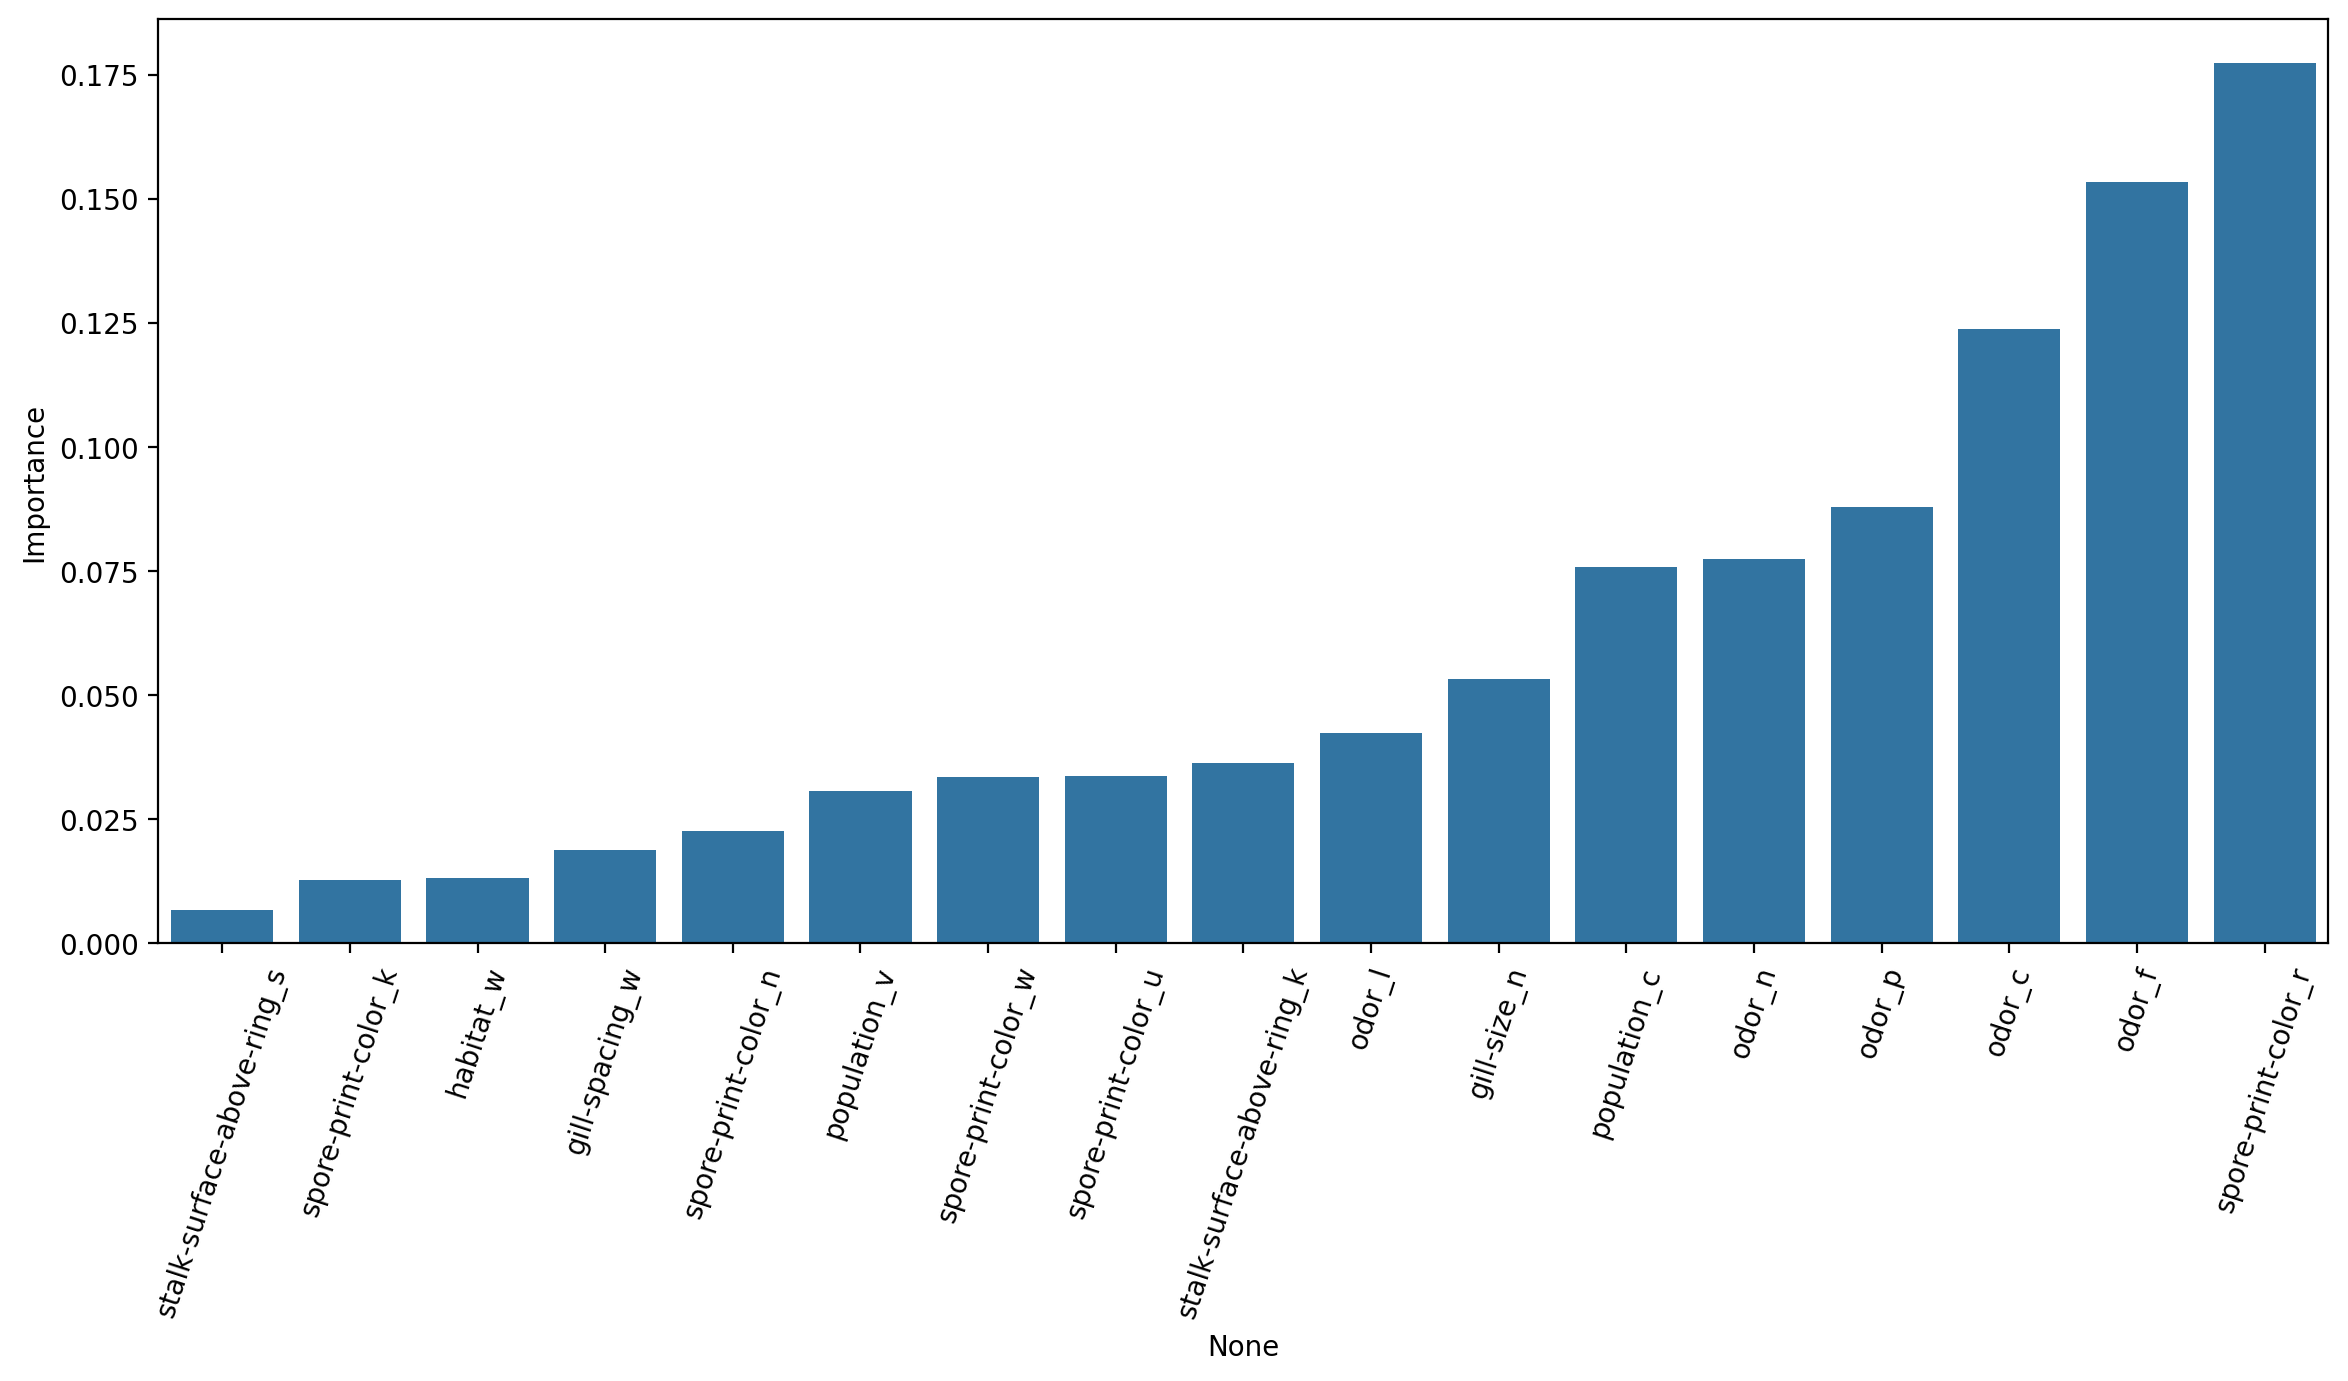

In [63]:
imp_feats = imp_feats.sort_values('Importance')
plt.figure(figsize=(14,6), dpi=200)
plt.xticks(rotation=72)
sns.barplot(data=imp_feats, x=imp_feats.index, y='Importance')

In [55]:
model = AdaBoostClassifier(n_estimators=95)

In [56]:
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           e       0.94      0.98      0.96       637
           p       0.97      0.94      0.96       582

    accuracy                           0.96      1219
   macro avg       0.96      0.96      0.96      1219
weighted avg       0.96      0.96      0.96      1219



In [64]:
feats = pd.DataFrame(index=X.columns, data=model.feature_importances_, columns=['Importance'])

In [65]:
imp_feats = feats[feats['Importance'] > 0]

<Axes: xlabel='None', ylabel='Importance'>

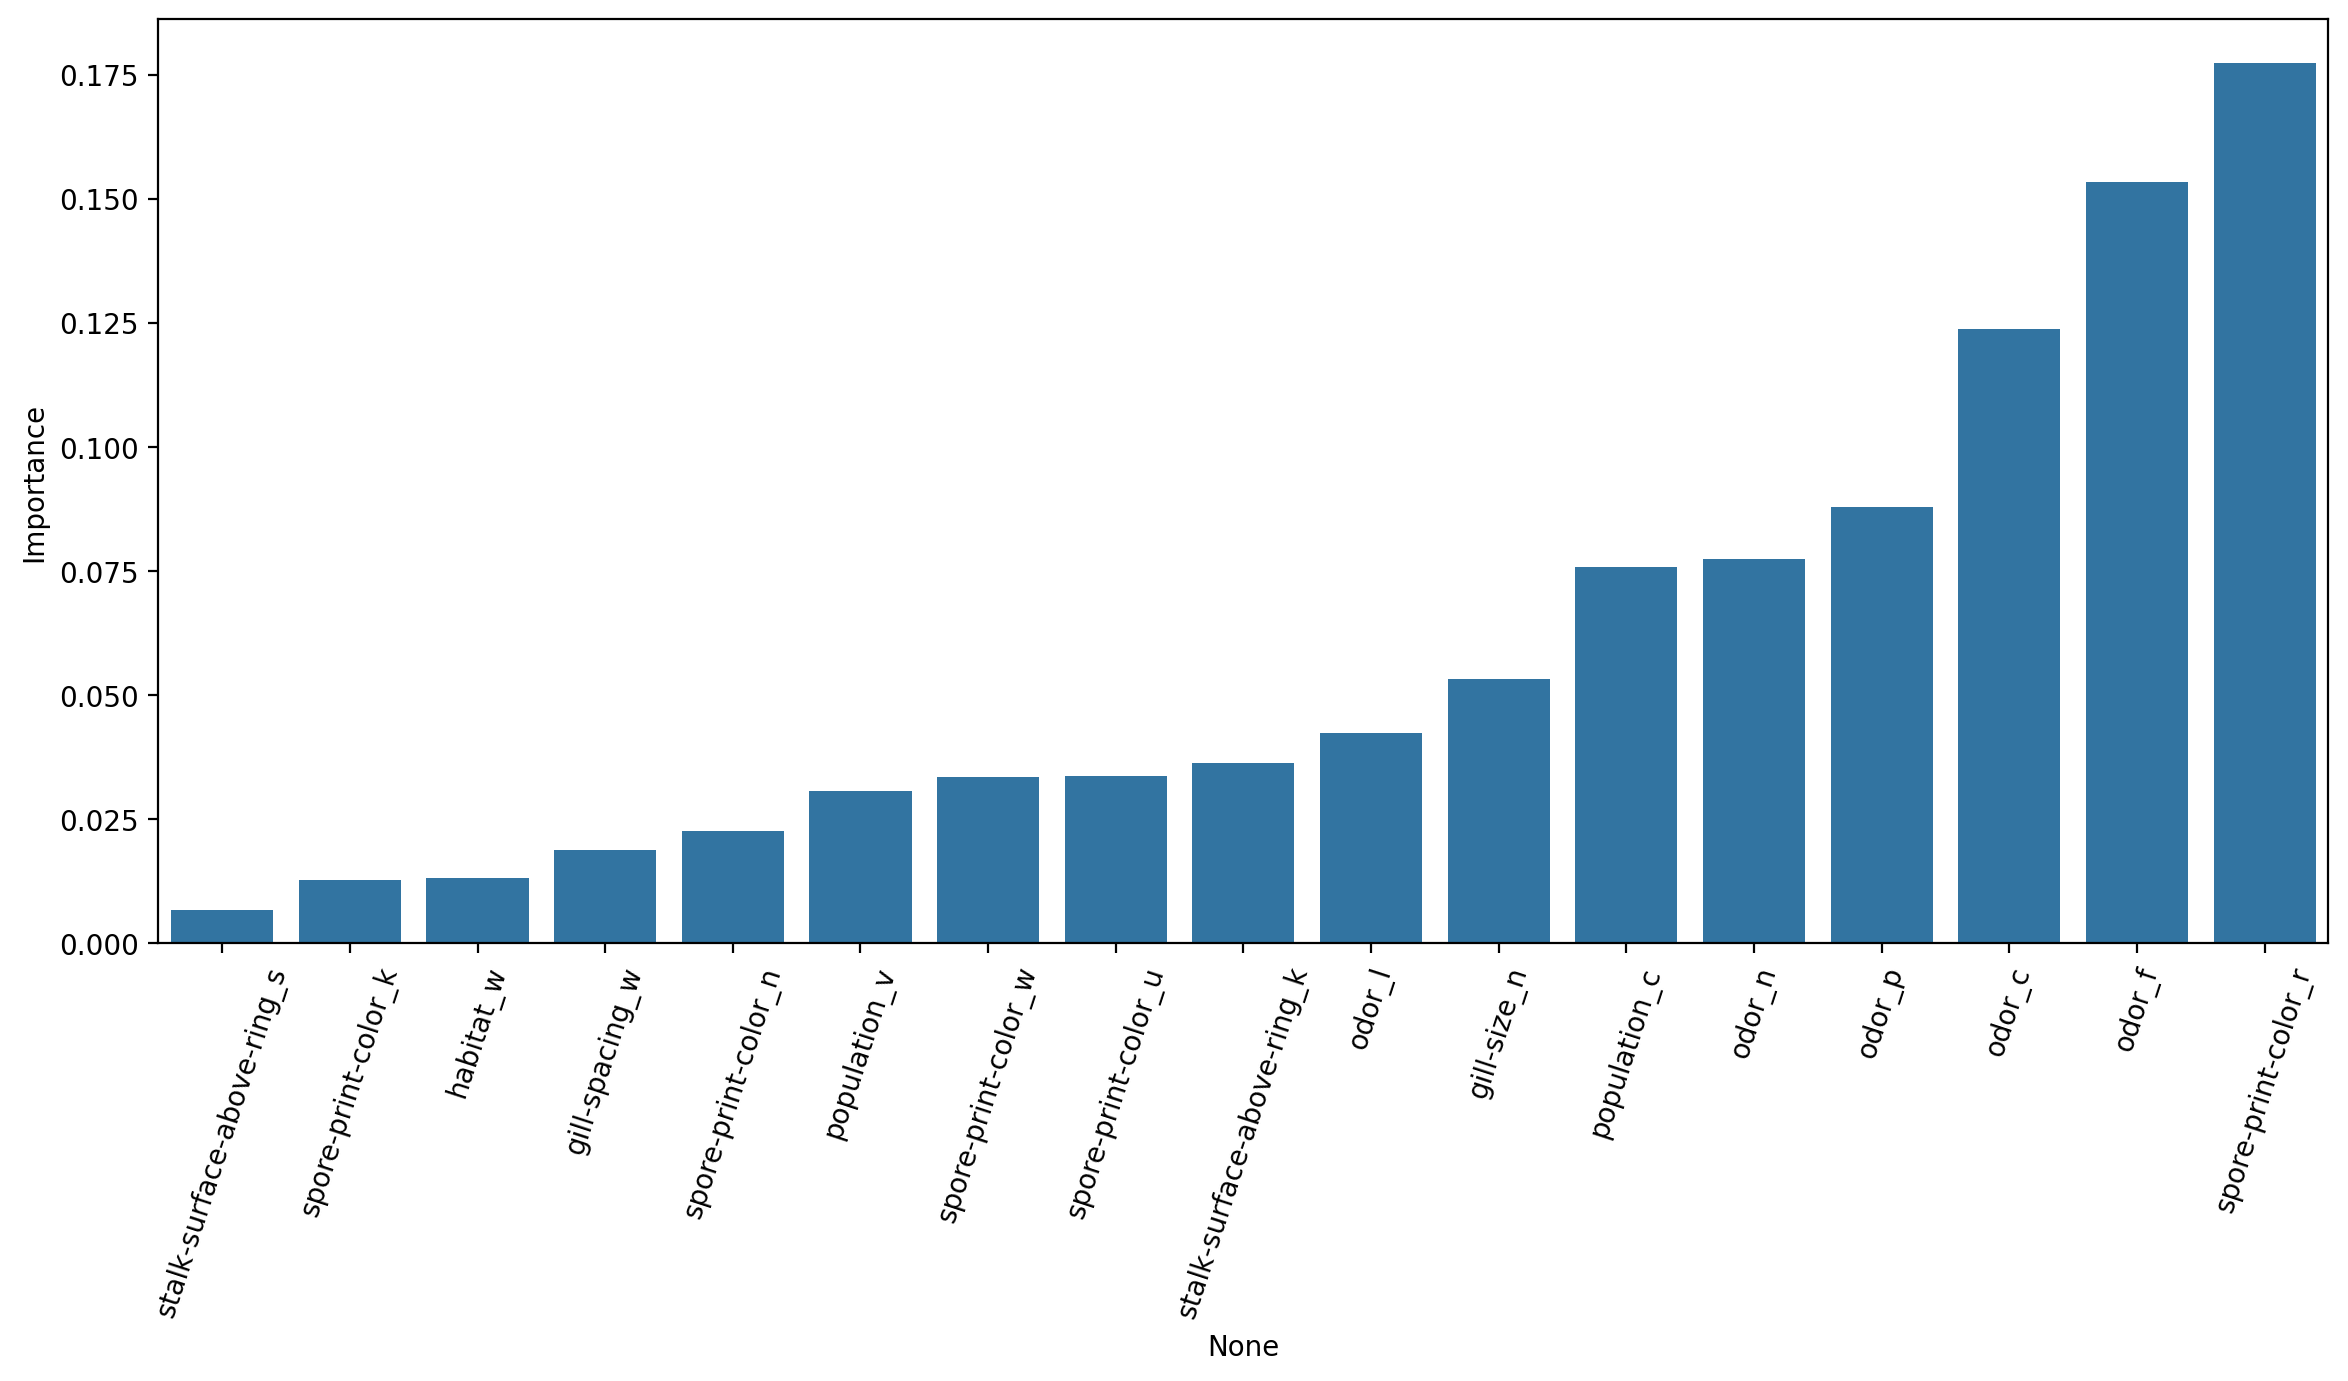

In [66]:
imp_feats = imp_feats.sort_values('Importance')
plt.figure(figsize=(14,6), dpi=200)
plt.xticks(rotation=72)
sns.barplot(data=imp_feats, x=imp_feats.index, y='Importance')